In [1]:
!pip install kaggle

In [7]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_8ada2dd669cc2242e08b61f88858ebcd"

In [8]:
!kaggle datasets list -s asl alphabet

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,config,auth}
              ...
kaggle: error: unrecognized arguments: alphabet


In [9]:
!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:10<00:00, 105MB/s] 



In [10]:
import zipfile

with zipfile.ZipFile("asl-alphabet.zip", "r") as zip_ref:
    zip_ref.extractall("asl_data")

In [18]:
classes = ['A', 'B', 'C', 'D', 'E']

In [20]:
import os
print(os.listdir())

['.config', 'asl-alphabet.zip', 'asl_data', 'sample_data']


In [21]:
import os
print(os.listdir("asl_data"))

['asl_alphabet_train', 'asl_alphabet_test']


In [23]:
import os

print(os.listdir("asl_data/asl_alphabet_train")[:20])

['asl_alphabet_train']


In [24]:
import os
import cv2
import numpy as np

classes = ['A', 'B', 'C', 'D', 'E']

data = []
labels = []

IMG_SIZE = 64

for label, cls in enumerate(classes):
    folder = f"asl_data/asl_alphabet_train/asl_alphabet_train/{cls}"

    count = 0
    for img_name in os.listdir(folder):
        if count >= 300:
            break

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        data.append(img)
        labels.append(label)

        count += 1

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1500, 64, 64, 3)
Labels shape: (1500,)


In [25]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

labels = to_categorical(labels)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1200, 64, 64, 3)
X_test: (300, 64, 64, 3)


In [26]:
TIMESTEPS = 10

def create_sequence(X):
    return np.repeat(X[:, np.newaxis, :, :, :], TIMESTEPS, axis=1)

X_train_seq = create_sequence(X_train)
X_test_seq = create_sequence(X_test)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)

X_train_seq: (1200, 10, 64, 64, 3)
X_test_seq: (300, 10, 64, 64, 3)


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM, Dense, Dropout

model = Sequential([
    TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                    input_shape=(TIMESTEPS, 64, 64, 3)),
    TimeDistributed(MaxPooling2D((2,2))),

    TimeDistributed(Conv2D(64, (3,3), activation='relu')),
    TimeDistributed(MaxPooling2D((2,2))),

    TimeDistributed(Flatten()),

    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 62, 62, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 31, 31, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 29, 29, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 14, 14, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 12544)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     3,227,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,251,781 (12.40 MB)

 Trainable params: 3,251,781 (12.40 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    X_train_seq, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 166s 5s/step - accuracy: 0.2208 - loss: 1.6258 - val_accuracy: 0.2750 - val_loss: 1.5698
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.3427 - loss: 1.4807 - val_accuracy: 0.5167 - val_loss: 1.3357
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.5583 - loss: 1.0927 - val_accuracy: 0.5500 - val_loss: 1.0491
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.6792 - loss: 0.7871 - val_accuracy: 0.7500 - val_loss: 0.6825
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.7396 - loss: 0.6707 - val_accuracy: 0.7750 - val_loss: 0.6180


In [29]:
loss, acc = model.evaluate(X_test_seq, y_test)
print("Test Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 611ms/step - accuracy: 0.8033 - loss: 0.5747
Test Accuracy: 0.8033333420753479


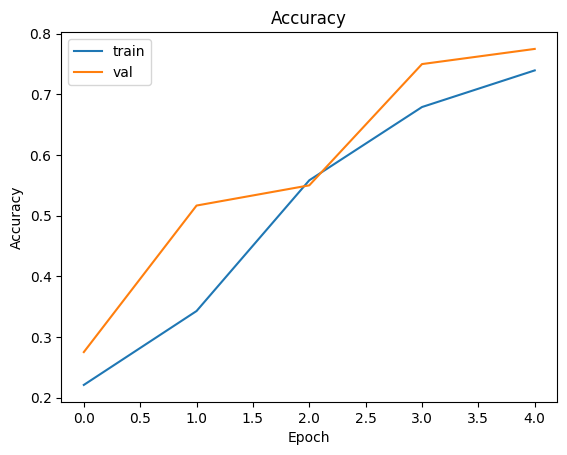

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 879ms/step


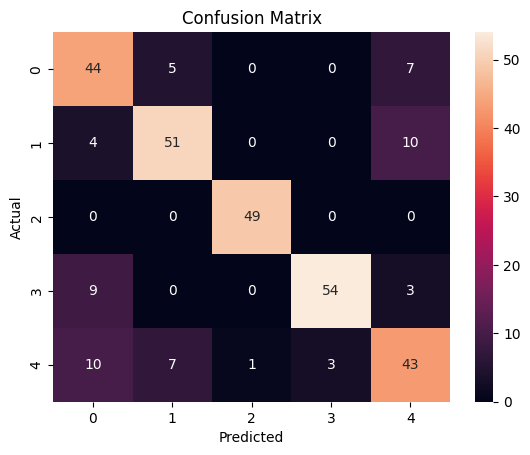

In [31]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

y_pred = model.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()